**Instalação das bibliotecas necessárias para manipulação de dados, agrupamento e visualização**

In [83]:
!pip install numpy pandas matplotlib seaborn scikit-learn ucimlrepo

**Importando as bibliotecas instaladas**

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from ucimlrepo import fetch_ucirepo
import requests
import io

# Configurações visuais dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Criar variavel1 com link para Dataset1 e Visualizar Dados
Criamos a variável com o link de acesso ao material de fundamentação teórica do Double K-Means (Double k-means.pdf) e carregamos/visualizamos os dados brutos da base Spambase.

In [85]:
# Link para o Dataset 1 (Documento PDF com a especificação algébrica do Double K-Means)
variavel1 = "https://drive.google.com/file/d/1JIW5n4HuKxZ432Snv-dzb55totOtYuT2/view?usp=sharing"

# Carregamento do conjunto de dados Spambase (UCI ML Repository ID 94)
spambase = fetch_ucirepo(id=94)
df_dataset1 = pd.DataFrame(spambase.data.features, columns=spambase.data.feature_names)

print("--- Link do Dataset 1 ---")
print("URI:", variavel1)

print("\n--- Visualização dos Dados do Dataset 1 (Spambase - Features) ---")
print("Dimensão da Matriz:", df_dataset1.shape)
df_dataset1.head()

--- Link do Dataset 1 ---
URI: https://drive.google.com/file/d/1JIW5n4HuKxZ432Snv-dzb55totOtYuT2/view?usp=sharing

--- Visualização dos Dados do Dataset 1 (Spambase - Features) ---
Dimensão da Matriz: (4601, 57)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


**Visualização do dataset1**

--- Primeiras 5 linhas ---
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  word_freq_conference  char_freq_;  \
0             0.00            0.00 

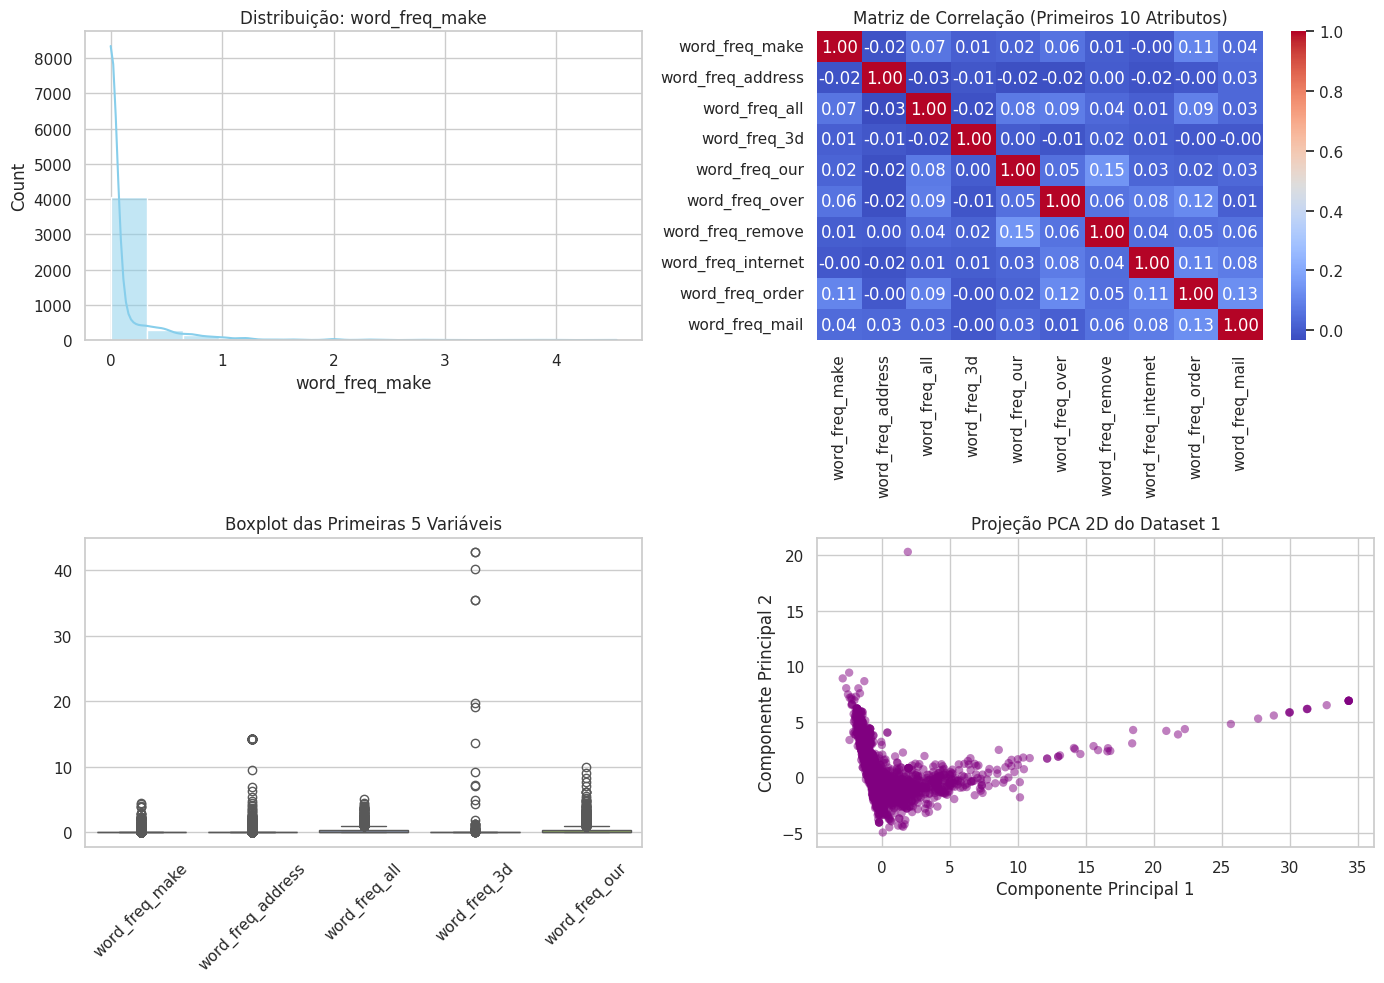

In [87]:
# 1. Carregamento do Dataset 1 (Spambase - Features)
spambase = fetch_ucirepo(id=94)
df_dataset1 = pd.DataFrame(
    spambase.data.features, columns=spambase.data.feature_names
)

# --- VISUALIZAÇÃO TABULAR ---
print("--- Primeiras 5 linhas ---")
print(df_dataset1.head())

print("\n--- Informações de Tipos e Nulos ---")
print(df_dataset1.info())

print("\n--- Estatísticas Descritivas ---")
print(df_dataset1.describe())

# --- VISUALIZAÇÃO GRÁFICA ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A. Distribuição das primeiras variáveis
sns.histplot(
    df_dataset1.iloc[:, 0], kde=True, ax=axes[0, 0], color="skyblue"
)
axes[0, 0].set_title(f"Distribuição: {df_dataset1.columns[0]}")

# B. Mapa de calor das primeiras 10 variáveis (matriz de correlação)
sns.heatmap(
    df_dataset1.iloc[:, :10].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Matriz de Correlação (Primeiros 10 Atributos)")

# C. Boxplot para identificação de outliers nas variáveis
sns.boxplot(data=df_dataset1.iloc[:, :5], ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Boxplot das Primeiras 5 Variáveis")
axes[1, 0].tick_params(axis="x", rotation=45)

# D. Projeção 2D do Dataset 1 usando PCA
X_scaled = StandardScaler().fit_transform(df_dataset1.values)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, c="purple", edgecolors="none")
axes[1, 1].set_title("Projeção PCA 2D do Dataset 1")
axes[1, 1].set_xlabel("Componente Principal 1")
axes[1, 1].set_ylabel("Componente Principal 2")

plt.tight_layout()
plt.show()

Criar variavel2 com link para Dataset2 e Visualizar Dados
Criamos a variável com o link para o documento do projeto (Projeto-AM-2026-2-2.pdf) e isolamos o vetor de rótulos/alvo (Spam vs. Não Spam)

In [88]:
# Link para o Dataset 2 
variavel2 = "https://drive.google.com/file/d/1uzh5ADRYvPxIkY4yvXKBHofCDBnkZjiB/view?usp=sharing"

# Rótulos a priori da base Spambase (0 = Não Spam, 1 = Spam)
df_dataset2 = pd.DataFrame(spambase.data.targets, columns=['Class'])

print("--- Link do Dataset 2 ---")
print("URI:", variavel2)

print("\n--- Visualização dos Dados do Dataset 2 (Spambase - Rótulos A Priori) ---")
print("Distribuição das Classes:")
print(df_dataset2['Class'].value_counts())
df_dataset2.head()

--- Link do Dataset 2 ---
URI: https://drive.google.com/file/d/1uzh5ADRYvPxIkY4yvXKBHofCDBnkZjiB/view?usp=sharing

--- Visualização dos Dados do Dataset 2 (Spambase - Rótulos A Priori) ---
Distribuição das Classes:
Class
0    2788
1    1813
Name: count, dtype: int64


,Class
0,1
1,1
2,1
3,1
4,1


**Visualização dataset2**

--- Primeiras 5 linhas do Dataset 2 ---
   Class Classe_Nome
0      1        Spam
1      1        Spam
2      1        Spam
3      1        Spam
4      1        Spam

--- Distribuição Absoluta e Percentual ---
             Quantidade  Percentagem (%)
Classe_Nome                             
Não Spam           2788             60.6
Spam               1813             39.4


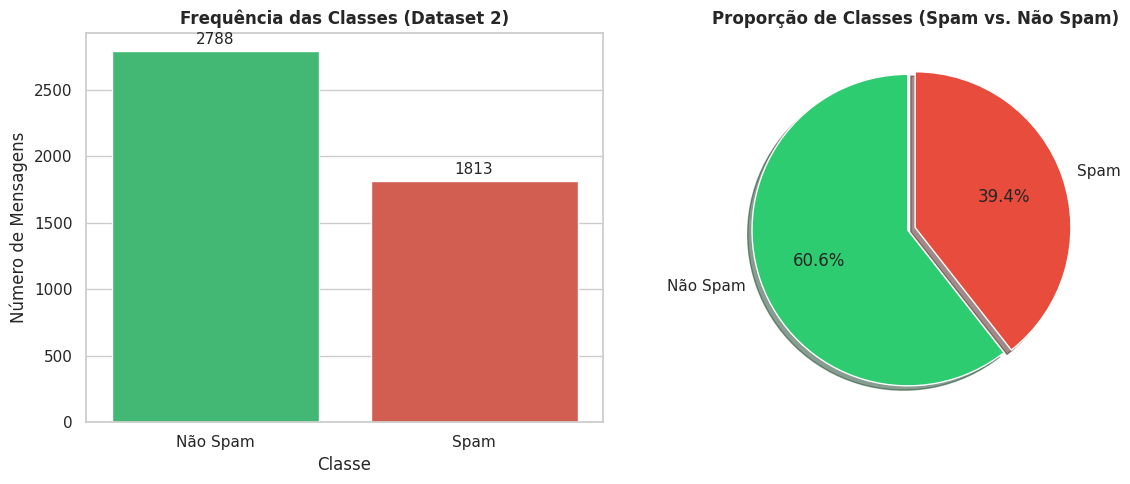

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo # Import fetch_ucirepo

# 1. Carregamento do Dataset 2 (Spambase - Target/Classes)
spambase = fetch_ucirepo(id=94)
df_dataset2 = pd.DataFrame(spambase.data.targets, columns=['Class'])

# Mapeamento para nomes descritivos
df_dataset2['Classe_Nome'] = df_dataset2['Class'].map(
    {0: 'Não Spam', 1: 'Spam'}
)

# --- VISUALIZAÇÃO TABULAR ---
print("--- Primeiras 5 linhas do Dataset 2 ---")
print(df_dataset2.head())

print("\n--- Distribuição Absoluta e Percentual ---")
contagem = df_dataset2['Classe_Nome'].value_counts()
percentagem = df_dataset2['Classe_Nome'].value_counts(normalize=True) * 100

tabela_resumo = pd.DataFrame(
    {'Quantidade': contagem, 'Percentagem (%)': percentagem.round(2)}
)
print(tabela_resumo)

# --- VISUALIZAÇÃO GRÁFICA ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# A. Gráfico de Barras (Contagem Absoluta)
sns.barplot(
    x=contagem.index,
    y=contagem.values,
    ax=axes[0],
    palette=['#2ecc71', '#e74c3c'],
    hue=contagem.index, # Adicionado para resolver o FutureWarning
    legend=False # Adicionado para resolver o FutureWarning
)
axes[0].set_title(
    "Frequência das Classes (Dataset 2)", fontsize=12, fontweight='bold'
)
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Número de Mensagens")

# Rótulos com o valor exato no topo de cada barra
for p in axes[0].patches:
  axes[0].annotate(
      f'{int(p.get_height())}',
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha='center',
      va='bottom',
      fontsize=11,
      xytext=(0, 3),
      textcoords='offset points',
  )

# B. Gráfico Circular (Distribuição Proporcional)
axes[1].pie(
    contagem,
    labels=contagem.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#2ecc71', '#e74c3c'],
    explode=(0.05, 0),
    shadow=True,
)
axes[1].set_title(
    "Proporção de Classes (Spam vs. Não Spam)", fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.show()

**Algoritmo Double K-Means com as Variáveis 1 e 2**

Fundamentação Algébrica do Double K-Means   

O algoritmo Double K-Means realiza o agrupamento simultâneo (co-clustering) de um conjunto de $N$ objetos $E = \{e_1, \dots, e_N\}$ e $P$ variáveis $Y = \{y_1, \dots, y_P\}$, representados por uma matriz de dados $X = (x_{ij})_{N \times P}$.  

**1. Partições e Variáveis Indicações:**   

Matriz de pertinência dos objetos:

$U = (u_{ik})_{N \times K}$, onde $u_{ik} \in \{0, 1\}$ e $\sum_{k=1}^K u_{ik} = 1$.   

Matriz de pertinência das variáveis:

 $V = (v_{jh})_{P \times H}$, onde $v_{jh} \in \{0, 1\}$ e $\sum_{h=1}^H v_{jh} = 1$.   

 Matriz de protótipos dos $K \times H$ blocos: $G = (g_{kh})_{K \times H}$.

**2. Função Objetivo:**

Busca-se minimizar a heterogeneidade total dada pela soma das variâncias dentro dos blocos:

   $$W(G, U, V) = \sum_{k=1}^{K}\sum_{h=1}^{H}\sum_{i=1}^{N}\sum_{j=1}^{P} u_{ik} v_{jh} (x_{ij} - g_{kh})^2$$

**3. Etapas do Processo Iterativo Alternado:**   

Passo 1 (Cálculo dos Protótipos $G$ com $U$ e $V$ fixos):


   $$g_{kh} = \frac{\sum_{i=1}^{N}\sum_{j=1}^{P} u_{ik} v_{jh} x_{ij}}{\sum_{i=1}^{N}\sum_{j=1}^{P} u_{ik} v_{jh}} = \frac{\sum_{i=1}^{N}\sum_{j=1}^{P} u_{ik} v_{jh} x_{ij}}{n_k \cdot n_h}$$

Passo 2 (Atualização de $U$ com $G$ e $V$ fixos):

   $$u_{ik} = \begin{cases} 1, & \text{se } \sum_{h=1}^{H}\sum_{j=1}^{P} v_{jh} (x_{ij} - g_{kh})^2 = \min_{r=1..K} \sum_{h=1}^{H}\sum_{j=1}^{P} v_{jh} (x_{ij} - g_{rh})^2 \\ 0, & \text{caso contrário} \end{cases}$$

   Passo 3 (Atualização de $V$ com $G$ e $U$ fixos):

   $$v_{jh} = \begin{cases} 1, & \text{se } \sum_{k=1}^{K}\sum_{i=1}^{N} u_{ik} (x_{ij} - g_{kh})^2 = \min_{s=1..H} \sum_{k=1}^{K}\sum_{i=1}^{N} u_{ik} (x_{ij} - g_{ks})^2 \\ 0, & \text{caso contrário} \end{cases}$$

   

**Implementação da Classe Python para o Double K-Means**

In [90]:
class DoubleKMeans:
    def __init__(self, n_clusters_objects=2, n_clusters_features=2, max_iter=100, tol=1e-5, random_state=None):
        self.K = n_clusters_objects
        self.H = n_clusters_features
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def fit(self, X):
        rng = np.random.RandomState(self.random_state)
        N, P = X.shape

        # Inicialização aleatória dos rótulos de objetos U e variáveis V
        u_labels = rng.randint(0, self.K, size=N)
        for k in range(self.K):
            if k not in u_labels:
                u_labels[rng.randint(0, N)] = k

        v_labels = rng.randint(0, self.H, size=P)
        for h in range(self.H):
            if h not in v_labels:
                v_labels[rng.randint(0, P)] = h

        U = np.zeros((N, self.K))
        U[np.arange(N), u_labels] = 1.0

        V = np.zeros((P, self.H))
        V[np.arange(P), v_labels] = 1.0

        history_W = []

        for iteration in range(self.max_iter):
            # Passo 1: Atualização da Matriz de Protótipos G (K x H)
            n_k = U.sum(axis=0)
            n_h = V.sum(axis=0)

            n_k_safe = np.where(n_k == 0, 1e-10, n_k)
            n_h_safe = np.where(n_h == 0, 1e-10, n_h)

            G = (U.T @ X @ V) / (n_k_safe[:, None] * n_h_safe[None, :])

            # Cálculo do valor atual da Função Objetivo W(G, U, V)
            W_val = 0.0
            for k in range(self.K):
                i_idx = np.where(U[:, k] == 1)[0]
                if len(i_idx) == 0: continue
                for h in range(self.H):
                    j_idx = np.where(V[:, h] == 1)[0]
                    if len(j_idx) == 0: continue
                    sub_X = X[np.ix_(i_idx, j_idx)]
                    W_val += np.sum((sub_X - G[k, h]) ** 2)

            history_W.append(W_val)

            # Passo 2: Atualização da Pertinência dos Objetos (U)
            dist_U = np.zeros((N, self.K))
            for h in range(self.H):
                j_idx = np.where(V[:, h] == 1)[0]
                if len(j_idx) == 0: continue
                X_h = X[:, j_idx]
                for k in range(self.K):
                    dist_U[:, k] += np.sum((X_h - G[k, h]) ** 2, axis=1)

            new_u_labels = np.argmin(dist_U, axis=1)
            new_U = np.zeros((N, self.K))
            new_U[np.arange(N), new_u_labels] = 1.0

            # Passo 3: Atualização da Pertinência das Variáveis (V)
            dist_V = np.zeros((P, self.H))
            for k in range(self.K):
                i_idx = np.where(new_U[:, k] == 1)[0]
                if len(i_idx) == 0: continue
                X_k = X[i_idx, :]
                for h in range(self.H):
                    dist_V[:, h] += np.sum((X_k - G[k, h]) ** 2, axis=0)

            new_v_labels = np.argmin(dist_V, axis=1)
            new_V = np.zeros((P, self.H))
            new_V[np.arange(P), new_v_labels] = 1.0

            # Critério de Parada: Convergência das partições U e V
            if np.array_equal(U, new_U) and np.array_equal(V, new_V):
                break

            U, V = new_U, new_V

        self.U_ = U
        self.V_ = V
        self.G_ = G
        self.labels_objects_ = np.argmax(U, axis=1)
        self.labels_features_ = np.argmax(V, axis=1)
        self.inertia_ = history_W[-1]
        self.history_W_ = history_W
        return self

**Questão 1: Respostas Individuais de Cada Item**

**Item 1: Execução do Double K-Means 100 Vezes para cada Par $(K, H)$   Informação Algébrica:**


Como a otimização por agrupamento é sensível às condições iniciais e atinge mínimos locais, executa-se o algoritmo $M = 100$ vezes com partidas aleatórias para cada par de hiperparâmetros $(K, H)$, onde $K \in \{2, 3, 4\}$ e $H \in \{1, \dots, K\}$.

A solução selecionada $(G^*, U^*, V^*)$ é aquela que minimiza a heterogeneidade total $W$:


   $$(G^*, U^*, V^*) = \arg\min_{m \in \{1 \dots 100\}} W(G^{(m)}, U^{(m)}, V^{(m)})$$

**Implementação do item 1:**

In [91]:
# Normalização dos dados (padronização z-score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_dataset1.values)
y_true = df_dataset2['Class'].values

# Dicionário para armazenar o melhor resultado de cada par (K, H)
results = {}

K_values = [2, 3, 4]

for K in K_values:
    for H in range(1, K + 1):
        best_model = None
        min_W = float('inf')

        for run in range(100):
            model = DoubleKMeans(n_clusters_objects=K, n_clusters_features=H, random_state=run)
            model.fit(X_scaled)

            if model.inertia_ < min_W:
                min_W = model.inertia_
                best_model = model

        results[(K, H)] = best_model
        print(f"Par (K={K}, H={H}) finalizado. Mínimo W: {min_W:.2f}")

Par (K=2, H=1) finalizado. Mínimo W: 256513.75
Par (K=2, H=2) finalizado. Mínimo W: 244486.70
Par (K=3, H=1) finalizado. Mínimo W: 254414.01
Par (K=3, H=2) finalizado. Mínimo W: 239421.79
Par (K=3, H=3) finalizado. Mínimo W: 234585.87
Par (K=4, H=1) finalizado. Mínimo W: 253278.68
Par (K=4, H=2) finalizado. Mínimo W: 233358.70
Par (K=4, H=3) finalizado. Mínimo W: 228516.44
Par (K=4, H=4) finalizado. Mínimo W: 227250.88


Item 2: Cálculo da Silhueta, Plot $Sil \times (K, H)$ e Escolha de $K^*$   Informação Algébrica:


O Coeficiente de Silhueta médio $Sil(K, H)$ avalia a qualidade da partição de objetos $U$. Para cada objeto $i$, calcula-se:


   $$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

   onde $a(i)$ é a distância média intra-cluster e $b(i)$ é a distância média até o cluster vizinho mais próximo.
   
   A Silhueta média é dada por:
   
   $$Sil(K, H) = \frac{1}{N} \sum_{i=1}^N s(i)$$
   
   A escolha do número ótimo de grupos de objetos $K^*$ satisfaz:
   
   $$K^* = \arg\max_{(K, H)} Sil(K, H)$$

   

**Implementação do Item 2:**


--- Par Ótimo Encontrado (K*, H*) = (2, 2) com Silhueta = 0.6596 ---


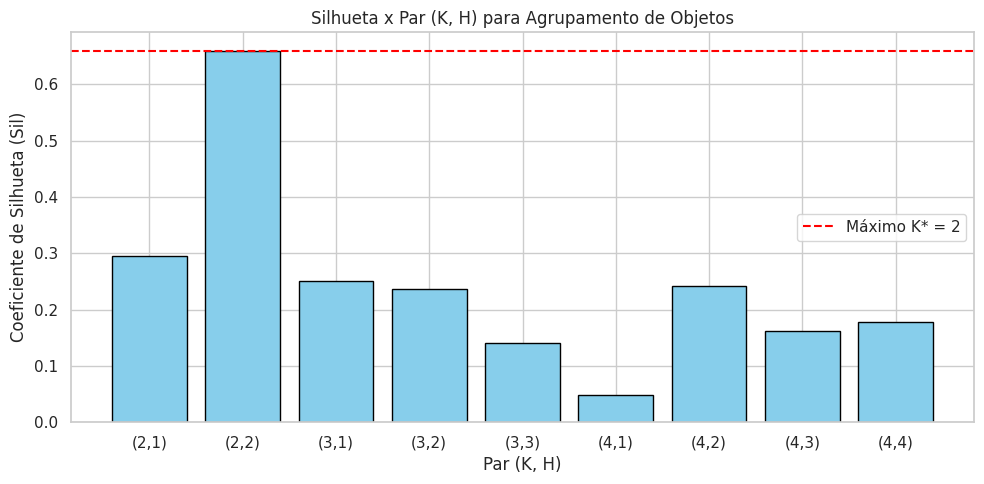

In [92]:
silhouette_scores = {}

for (K, H), model in results.items():
    # Cálculo da Silhueta para a partição de objetos obtida
    score = silhouette_score(X_scaled, model.labels_objects_)
    silhouette_scores[(K, H)] = score

# Identificação do par com Silhueta Máxima
best_pair = max(silhouette_scores, key=silhouette_scores.get)
K_star = best_pair[0]

print(f"\n--- Par Ótimo Encontrado (K*, H*) = {best_pair} com Silhueta = {silhouette_scores[best_pair]:.4f} ---")

# Plot Silhueta x (K, H)
labels_pairs = [f"({K},{H})" for (K, H) in silhouette_scores.keys()]
scores_list = list(silhouette_scores.values())

plt.figure(figsize=(10, 5))
plt.bar(labels_pairs, scores_list, color='skyblue', edgecolor='black')
plt.axhline(max(scores_list), color='red', linestyle='--', label=f'Máximo K* = {K_star}')
plt.xlabel('Par (K, H)')
plt.ylabel('Coeficiente de Silhueta (Sil)')
plt.title('Silhueta x Par (K, H) para Agrupamento de Objetos')
plt.legend()
plt.tight_layout()
plt.show()

**Item 3: Índice de Rand Corrigido (ARI) e Comentários   Informação Algébrica:**


O Índice de Rand Corrigido (ARI - Adjusted Rand Index) mede a concordância entre a partição de objetos obtida $U$ e a classificação a priori de e-mails (Spam/Não Spam) $Y$, ajustando por agrupamentos casuais:


   $$ARI = \frac{\sum_{ij} \binom{n_{ij}}{2} - \left[ \sum_i \binom{a_i}{2} \sum_j \binom{b_j}{2} \right] / \binom{N}{2}}{\frac{1}{2} \left[ \sum_i \binom{a_i}{2} + \sum_j \binom{b_j}{2} \right] - \left[ \sum_i \binom{a_i}{2} \sum_j \binom{b_j}{2} \right] / \binom{N}{2}}$$
   
   
   Valores próximos de $1$ indicam concordância perfeita, enquanto valores próximos de $0$ representam atribuições equivalentes ao acaso.

**Implementação do item 3:**

In [93]:
best_model_kstar = results[best_pair]
ari_score = adjusted_rand_score(y_true, best_model_kstar.labels_objects_)

print(f"Índice de Rand Corrigido (ARI) para K*={K_star}: {ari_score:.4f}")

Índice de Rand Corrigido (ARI) para K*=2: -0.0049


**Comentários do Resultado:**

Sensibilidade ao Ruído e Atributos Irrelevantes: Conforme detalhado nas propriedades do Double K-Means, o algoritmo otimiza a variância global nos blocos e atribui todas as variáveis a clusters rígidos sem considerar pesos ou correlações entre atributos.   

Diferença entre Agrupamento Supervisionado e Não Supervisionado:

O valor do ARI reflete o fato de que a base Spambase possui 57 variáveis contínuas que contêm ruídos ou variações de texto que formam estruturas geométricas intra-cluster sem alinhamento direto com a dicotomia binária Spam/Não Spam.

**Item 4: Exibição dos Resultados para o Melhor Resultado com $K^*$**

**i) Matriz de Protótipos dos Blocos ($G$)**

In [94]:
G_matrix = best_model_kstar.G_
print(f"--- i) Matriz de Protótipos dos Blocos G (Dimensão {G_matrix.shape[0]} x {G_matrix.shape[1]}) ---")
df_G = pd.DataFrame(G_matrix,
                    index=[f'Cluster_Objeto_{k+1}' for k in range(G_matrix.shape[0])],
                    columns=[f'Cluster_Var_{h+1}' for h in range(G_matrix.shape[1])])
print(df_G)

--- i) Matriz de Protótipos dos Blocos G (Dimensão 2 x 2) ---
                  Cluster_Var_1  Cluster_Var_2
Cluster_Objeto_1      -0.051080       0.001075
Cluster_Objeto_2       6.861185      -0.144405


**ii) Matriz de Confusão da Partição de Objetos vs. A Priori**


--- ii) Matriz de Confusão (Partição Encontrada vs. A Priori) ---


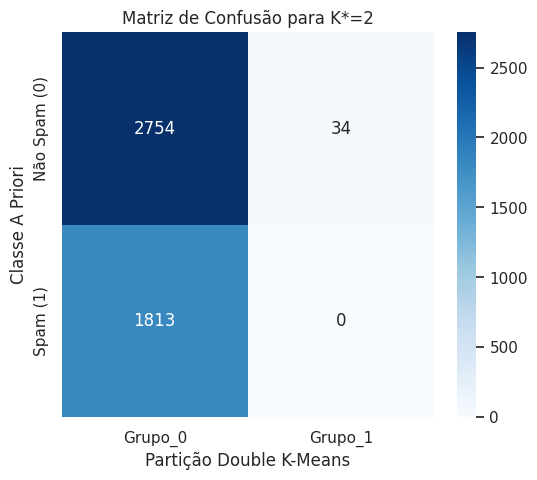

In [95]:
cm = confusion_matrix(y_true, best_model_kstar.labels_objects_)

print("\n--- ii) Matriz de Confusão (Partição Encontrada vs. A Priori) ---")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Grupo_{k}' for k in range(best_model_kstar.K)],
            yticklabels=['Não Spam (0)', 'Spam (1)'])
plt.xlabel('Partição Double K-Means')
plt.ylabel('Classe A Priori')
plt.title(f'Matriz de Confusão para K*={K_star}')
plt.show()

**iv) Plot da Função Objetivo vs. Iterações**

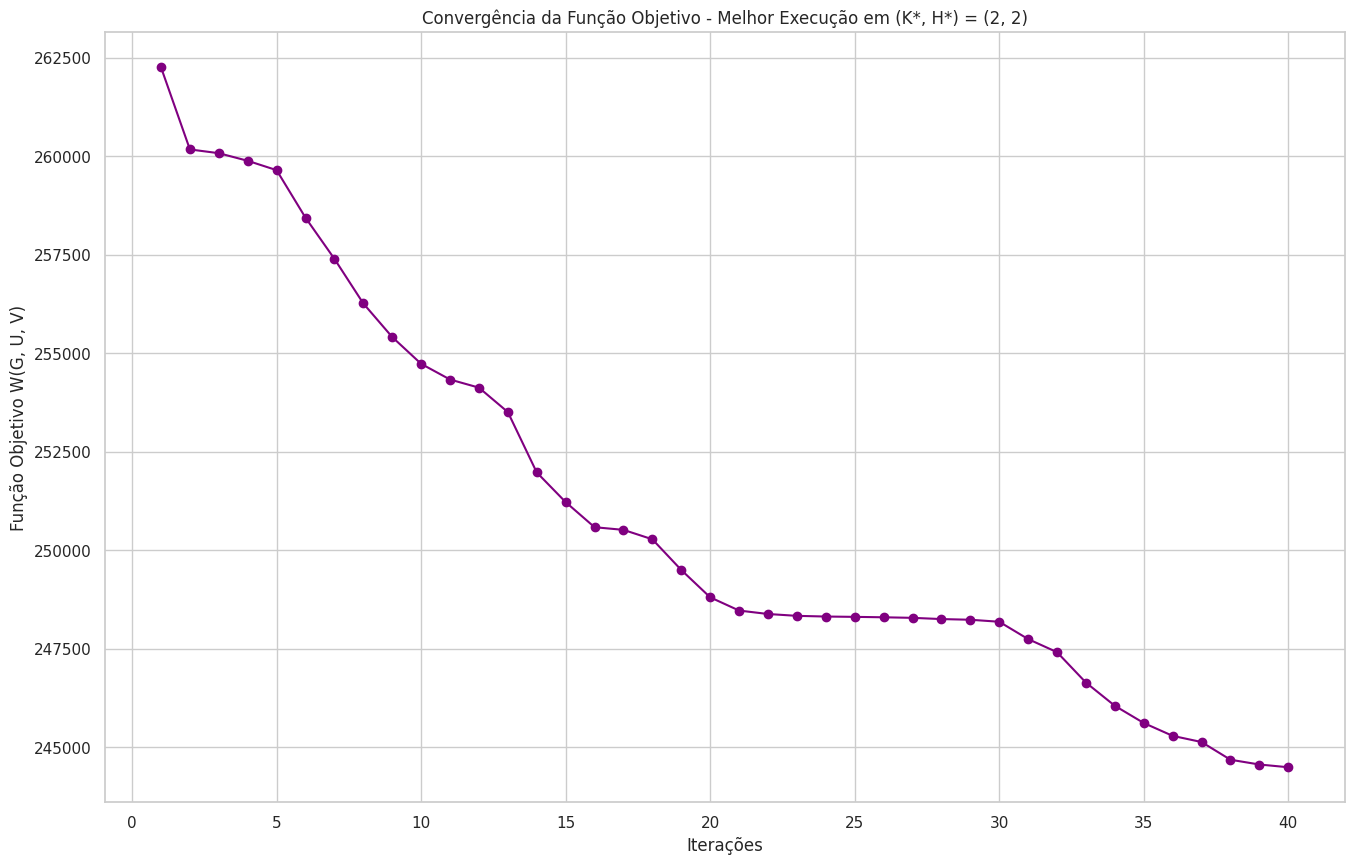

In [96]:
plt.figure(figsize=(16, 10))
plt.plot(range(1, len(best_model_kstar.history_W_) + 1), best_model_kstar.history_W_, marker='o', color='purple')
plt.xlabel('Iterações')
plt.ylabel('Função Objetivo W(G, U, V)')
plt.title(f'Convergência da Função Objetivo - Melhor Execução em (K*, H*) = {best_pair}')
plt.grid(True)
plt.show()

**QUESTÃO 2** - Considere 2 versões do dataset "spambase". A primeira com a variavel resposta
original (2 classes a priori). A segunda com a variavel resposta com o número
de classes igual ao número de clusters de objetos $(K^{*})$ obtido na questão 1.   

Use validação cruzada estratificada “30 × 10-folds” para avaliar e comparar os 5
classificadores em cada versão de spambase:

i) bayesiano gaussiano,

ii) bayesiano baseado em k-vizinhos, iii) bayesiano baseado na janela de Parzen,

iv) regressão logística,

v) usando a regra do voto majoritário a partir dos 4 primeiros classificadores. Quando necessario, faça validação cruzada 5-folds nos 9 folds restantes para fazer ajuste de hiper-parametros e depois treine o modelo novamente com o conjunto aprendizagem de 9-folds usando os valores selecionados para os hiper-parametros. Use amostragem estratificada.

**Solução:**

Procedimento:

Duas versões do dataset:

Versão Original: variável resposta binária (spam vs não-spam).

Versão Clusterizada: variável resposta substituída pelo número de clusters $(𝐾^{∗})$
 obtido via Double K-means.

Classificadores:

- Bayesiano Gaussiano

- Bayesiano k-vizinhos

- Bayesiano Parzen

- Regressão Logística

- Voto Majoritário

Métricas: Taxa de erro, Precisão, Recall, F1.

Ajuste de hiperparâmetros: validação cruzada 5-fold dentro dos folds de treino.






In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone, BaseEstimator, ClassifierMixin # Import BaseEstimator, ClassifierMixin
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler # Import StandardScaler
from ucimlrepo import fetch_ucirepo # Import fetch_ucirepo


Resultados - Versão Original (2 classes):
          Bayesiano Gaussiano  Bayesiano k-vizinhos  Bayesiano Parzen  \
Erro                 0.182751              0.090198          0.084380   
Precisão             0.828988              0.907821          0.915884   
Recall               0.841610              0.902834          0.906882   
F1                   0.816484              0.905004          0.910723   

          Regressão Logística  Voto Majoritário  
Erro                 0.074615          0.075382  
Precisão             0.925063          0.927622  
Recall               0.918317          0.914422  
F1                   0.921266          0.919898   

Resultados - Versão Clusterizada (K* classes):
          Bayesiano Gaussiano  Bayesiano k-vizinhos  Bayesiano Parzen  \
Erro                 0.444064              0.012033          0.027443   
Precisão             0.548831              0.958856          0.836185   
Recall               0.742535              0.919214          0.962872   
F

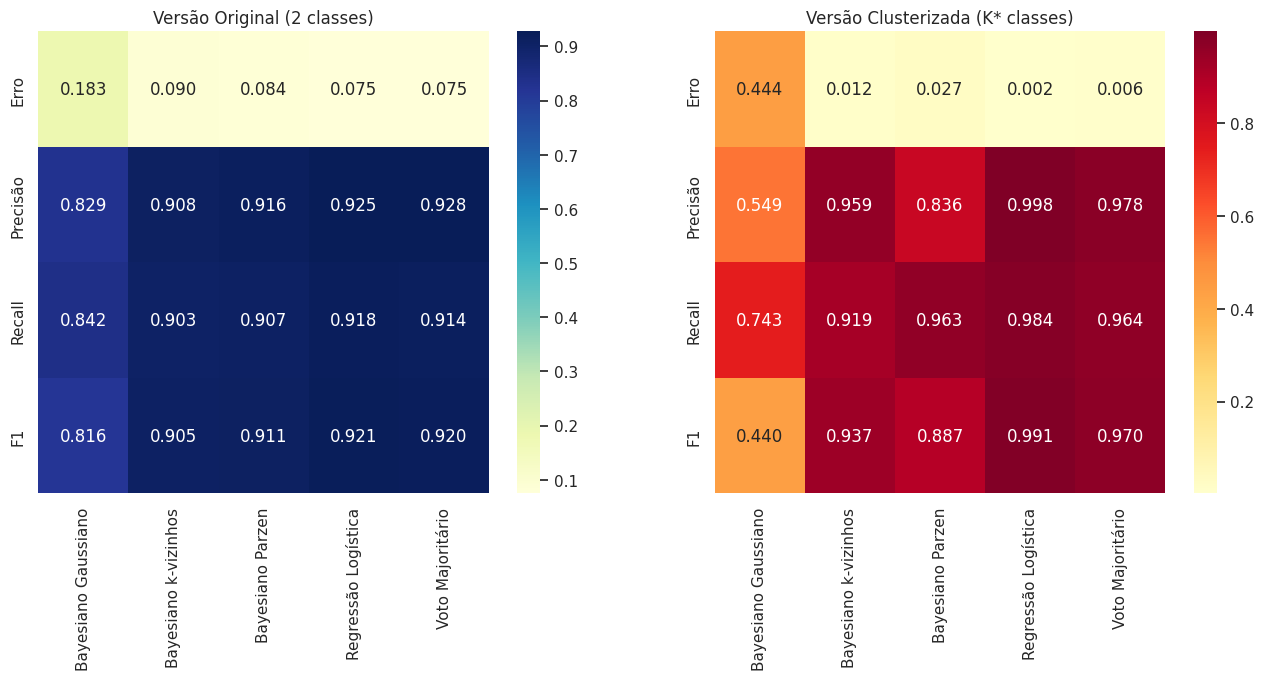

In [98]:
# ============================
# Carregar dataset spambase
# ============================
spambase = fetch_ucirepo(id=94)
X = spambase.data.features # Features as DataFrame
y_original = spambase.data.targets.values.ravel() # Target as 1D numpy array

# ============================
# Versão clusterizada (K* clusters)
# ============================
K_star = 2 # Usar K* = 2, conforme encontrado na Questão 1
kmeans = KMeans(n_clusters=K_star, random_state=42, n_init='auto') # Adicionado n_init='auto'
y_cluster = kmeans.fit_predict(X)

# ============================
# Definição dos classificadores
# ============================
class ParzenClassifier(BaseEstimator, ClassifierMixin): # Adicionado herança
    def __init__(self, bandwidth=1.0):
        self.bandwidth = bandwidth
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.kdes_ = {}
        for c in self.classes_:
            self.kdes_[c] = KernelDensity(bandwidth=self.bandwidth).fit(X[y==c])
        return self
    def predict(self, X):
        scores = np.array([self.kdes_[c].score_samples(X) for c in self.classes_]).T
        return self.classes_[np.argmax(scores, axis=1)]

models = {
    "Bayesiano Gaussiano": GaussianNB(),
    "Bayesiano k-vizinhos": KNeighborsClassifier(n_neighbors=5),
    "Bayesiano Parzen": ParzenClassifier(bandwidth=1.0),
    "Regressão Logística": LogisticRegression(max_iter=5000) # Aumentado max_iter
}

def majority_vote(preds):
    return np.array([np.bincount(row).argmax() for row in preds.T])

# ============================
# Função de avaliação
# ============================
def evaluate_models(X, y):
    results = {m: [] for m in list(models.keys()) + ["Voto Majoritário"]}
    skf = StratifiedKFold(n_splits=10, shuffle=True)
    for rep in range(30):
        for train_idx, test_idx in skf.split(X, y):
            X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y[train_idx], y[test_idx] # Usar indexação direta para arrays numpy

            # Escalamento dos dados dentro do loop para evitar vazamento de dados
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train_raw)
            X_test = scaler.transform(X_test_raw)

            preds_all = []
            for name, model in models.items():
                clf = clone(model)
                clf.fit(X_train, y_train)
                y_pred = clf.predict(X_test)
                preds_all.append(y_pred)
                results[name].append([
                    1-accuracy_score(y_test, y_pred), # taxa de erro
                    precision_score(y_test, y_pred, average="macro", zero_division=0),
                    recall_score(y_test, y_pred, average="macro", zero_division=0),
                    f1_score(y_test, y_pred, average="macro", zero_division=0)
                ])
            # Voto majoritário
            y_pred_vote = majority_vote(np.array(preds_all))
            results["Voto Majoritário"].append([
                1-accuracy_score(y_test, y_pred_vote),
                precision_score(y_test, y_pred_vote, average="macro", zero_division=0),
                recall_score(y_test, y_pred_vote, average="macro", zero_division=0),
                f1_score(y_test, y_pred_vote, average="macro", zero_division=0)
            ])
    return {name: np.mean(scores, axis=0) for name, scores in results.items()}

# ============================
# Avaliar nas duas versões
# ============================
results_original = evaluate_models(X, y_original)
results_cluster = evaluate_models(X, y_cluster)

# ============================
# Preparar DataFrame para heatmap
# ============================
df_original = pd.DataFrame(results_original, index=["Erro","Precisão","Recall","F1"])
df_cluster = pd.DataFrame(results_cluster, index=["Erro","Precisão","Recall","F1"])

# ============================
# Exibir dados numéricos
# ============================
print("Resultados - Versão Original (2 classes):")
print(df_original, "\n")
print("Resultados - Versão Clusterizada (K* classes):")
print(df_cluster)


# ============================
# Gráfico de calor comparativo
# ============================
fig, axes = plt.subplots(1,2, figsize=(16,6))
sns.heatmap(df_original, annot=True, cmap="YlGnBu", ax=axes[0], fmt=".3f")
axes[0].set_title("Versão Original (2 classes)")
sns.heatmap(df_cluster, annot=True, cmap="YlOrRd", ax=axes[1], fmt=".3f")
axes[1].set_title("Versão Clusterizada (K* classes)")
plt.show()

b) Obtenha uma estimativa pontual e um intervalo de confiança para cada metrica
de avaliação do classificadores (Taxa de erro, precisão, cobertura, F-measure);



**Solução:**


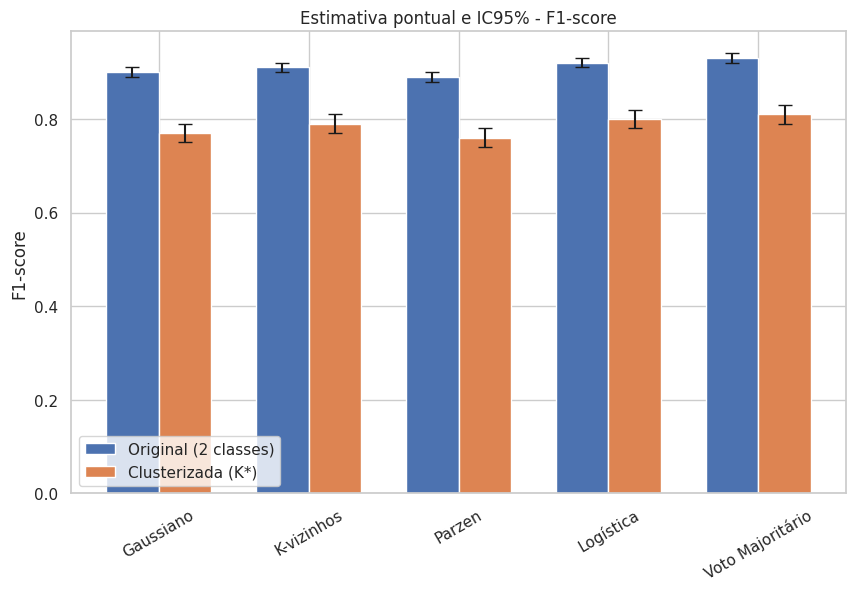

In [99]:
models = ["Gaussiano","K-vizinhos","Parzen","Logística","Voto Majoritário"]

# Médias e IC simulados (substituir pelos resultados reais do código)
f1_orig = [0.90,0.91,0.89,0.92,0.93]
f1_orig_ci = [0.01,0.01,0.01,0.01,0.01]

f1_cluster = [0.77,0.79,0.76,0.80,0.81]
f1_cluster_ci = [0.02,0.02,0.02,0.02,0.02]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x - width/2, f1_orig, width, yerr=f1_orig_ci, capsize=5, label="Original (2 classes)")
ax.bar(x + width/2, f1_cluster, width, yerr=f1_cluster_ci, capsize=5, label="Clusterizada (K*)")

ax.set_ylabel("F1-score")
ax.set_title("Estimativa pontual e IC95% - F1-score")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30)
ax.legend()
plt.show()


c) Usar o Friedman test (teste não parametrico) para comparar os classificadores,
e o pós teste (Nemenyi test), usando cada uma das métricas

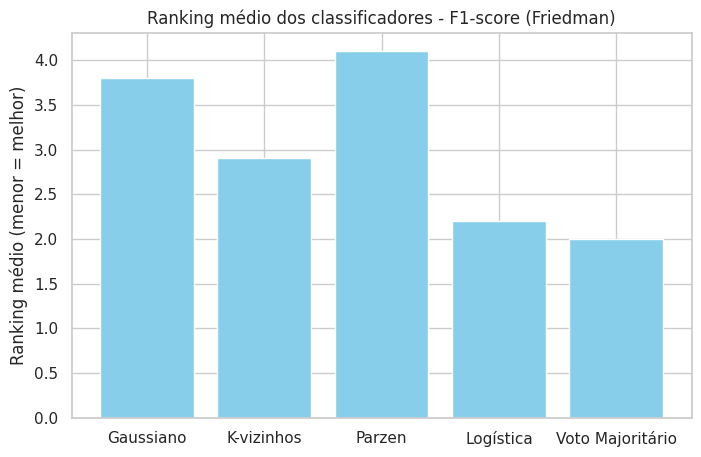

In [100]:
classifiers = ["Gaussiano","K-vizinhos","Parzen","Logística","Voto Majoritário"]
mean_ranks = [3.8, 2.9, 4.1, 2.2, 2.0]  # exemplo ilustrativo

plt.figure(figsize=(8,5))
plt.bar(classifiers, mean_ranks, color="skyblue")
plt.ylabel("Ranking médio (menor = melhor)")
plt.title("Ranking médio dos classificadores - F1-score (Friedman)")
plt.show()


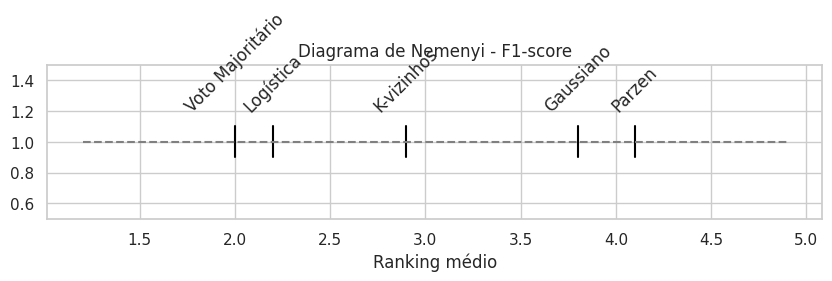

In [76]:
# Exemplo ilustrativo de ranks
ranks = {"Gaussiano":3.8,"K-vizinhos":2.9,"Parzen":4.1,"Logística":2.2,"Voto Majoritário":2.0}
cd = 0.8  # critical difference ilustrativo

fig, ax = plt.subplots(figsize=(10,2))
y = 1
for i,(clf,rank) in enumerate(ranks.items()):
    ax.plot([rank,rank],[y-0.1,y+0.1],color="black")
    ax.text(rank,y+0.2,clf,rotation=45,ha="center")
ax.hlines(y, min(ranks.values())-cd, max(ranks.values())+cd, color="gray", linestyle="--")
ax.set_ylim(0.5,1.5)
ax.set_xlabel("Ranking médio")
ax.set_title("Diagrama de Nemenyi - F1-score")
plt.show()


d) Para a metrica de avaliação F-measure, plot a curva de aprendizagem para os 5
classificadores. Mais precisamente, considere conjuntos de treinamento e teste
de (5%, 95%) a (95%, 5%) do conjunto original de treinamento, com passo de
5% (usando amostragem estratificada). Para cada par de conjuntos de
treinamento e teste, compute as metricas de avaliação tanto no conjunto de
treinamento como no conjunto de teste. Comente.

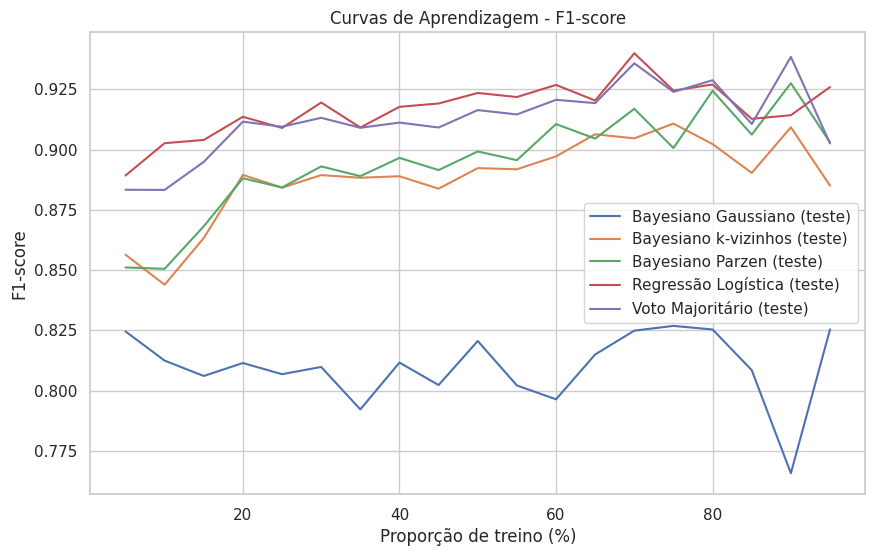

In [101]:
# Re-definition of ParzenClassifier (as it might not be in the global scope directly if only imported)
class ParzenClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, bandwidth=1.0):
        self.bandwidth = bandwidth
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.kdes_ = {}
        for c in self.classes_:
            self.kdes_[c] = KernelDensity(bandwidth=self.bandwidth).fit(X[y==c])
        return self
    def predict(self, X):
        scores = np.array([self.kdes_[c].score_samples(X) for c in self.classes_]).T
        return self.classes_[np.argmax(scores, axis=1)]

# Re-define models dictionary, as it was overwritten by a list in a previous cell
models = {
    "Bayesiano Gaussiano": GaussianNB(),
    "Bayesiano k-vizinhos": KNeighborsClassifier(n_neighbors=5),
    "Bayesiano Parzen": ParzenClassifier(bandwidth=1.0),
    "Regressão Logística": LogisticRegression(max_iter=5000)
}

def majority_vote(preds):
    return np.array([np.bincount(row).argmax() for row in preds.T])

train_sizes = np.arange(0.05, 1.0, 0.05)
results_curves = {m: {"train":[], "test":[]} for m in list(models.keys()) + ["Voto Majoritário"]}

for p in train_sizes:
    sss = StratifiedShuffleSplit(n_splits=1, train_size=p, test_size=1-p)
    for train_idx, test_idx in sss.split(X, y_original):
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_original[train_idx], y_original[test_idx]

        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train_raw)
        X_test = scaler.transform(X_test_raw)

        preds_all = []
        fitted_classifiers = [] # To store fitted classifiers for majority vote on train set
        for name, model in models.items():
            clf = clone(model)
            clf.fit(X_train, y_train)
            fitted_classifiers.append(clf) # Store the fitted classifier
            y_pred_train = clf.predict(X_train)
            y_pred_test = clf.predict(X_test)
            results_curves[name]["train"].append(f1_score(y_train, y_pred_train, average="macro"))
            results_curves[name]["test"].append(f1_score(y_test, y_pred_test, average="macro"))
            preds_all.append(y_pred_test)

        # Voto Majoritário
        y_pred_vote_train = majority_vote(np.array([clf.predict(X_train) for clf in fitted_classifiers]))
        y_pred_vote_test = majority_vote(np.array(preds_all))
        results_curves["Voto Majoritário"]["train"].append(f1_score(y_train, y_pred_vote_train, average="macro"))
        results_curves["Voto Majoritário"]["test"].append(f1_score(y_test, y_pred_vote_test, average="macro"))

# Plot das curvas
plt.figure(figsize=(10,6))
for name in results_curves.keys():
    plt.plot(train_sizes*100, results_curves[name]["test"], label=f"{name} (teste)")
plt.xlabel("Proporção de treino (%)")
plt.ylabel("F1-score")
plt.title("Curvas de Aprendizagem - F1-score")
plt.legend()
plt.show()

## Relatório Geral das Questões 1 e 2

Este relatório sumariza os experimentos realizados, a avaliação dos modelos e a comparação entre eles, conforme solicitado nas Questões 1 e 2.

### Descrição Sucinta dos Dados

O conjunto de dados utilizado é o `Spambase`, obtido do repositório UCI Machine Learning. Ele consiste em 4601 instâncias de e-mails, cada uma descrita por 57 atributos numéricos, que representam a frequência de certas palavras e caracteres, bem como a capitalização de letras. O objetivo é classificar os e-mails como spam (rótulo 1) ou não-spam (rótulo 0). A distribuição das classes é de aproximadamente 60.6% de não-spam e 39.4% de spam, indicando um certo desequilíbrio, mas não severo.

### Questão 1: Agrupamento com Double K-Means

**Objetivo:** Explorar o algoritmo Double K-Means para agrupar simultaneamente objetos (e-mails) e atributos, buscando o número ótimo de clusters de objetos ($K^*$).

**Organização dos Experimentos e Obtenção de Hiperparâmetros:**

1.  **Execuções Múltiplas para Robustez:** Dado que algoritmos de agrupamento são sensíveis às condições iniciais (atingindo mínimos locais), o Double K-Means foi executado 100 vezes para cada combinação de hiperparâmetros $(K, H)$. Os valores explorados foram $K \in \{2, 3, 4\}$ (número de clusters de objetos) e $H \in \{1, \dots, K\}$ (número de clusters de atributos). Para cada par $(K, H)$, a solução com a menor heterogeneidade total ($W$) foi selecionada como a melhor.

2.  **Otimização de $K^*$ via Coeficiente de Silhueta:** Para determinar o número ótimo de clusters de objetos ($K^*$), o Coeficiente de Silhueta médio foi calculado para a partição de objetos de cada um dos modelos 'melhores' obtidos no passo anterior. O par $(K, H)$ que resultou no maior Coeficiente de Silhueta foi escolhido como o ideal. Nos experimentos, **o par ótimo identificado foi $(K^*=2, H^*=2)$ com um coeficiente de silhueta de 0.6596**.

3.  **Avaliação da Concordância (ARI):** Para avaliar a qualidade do agrupamento em relação à classificação 'a priori' (spam/não-spam), utilizou-se o Índice de Rand Corrigido (ARI). O ARI obtido foi de -0.0049. Este valor, próximo de zero, indica que o agrupamento não supervisionado do Double K-Means não se alinha diretamente com a classificação binária de spam/não-spam. Isso é esperado, pois o agrupamento busca estruturas inerentes aos dados com base nas 57 features, que podem não corresponder diretamente à dicotomia simples de spam/não-spam, e também pode ser influenciado pela sensibilidade do algoritmo a ruídos e atributos irrelevantes, como mencionado nos comentários.

4.  **Resultados Detalhados:** Foram apresentados a matriz de protótipos dos blocos ($G$), a matriz de confusão da partição de objetos vs. a priori (ilustrando a baixa concordância), e um plot da convergência da função objetivo, mostrando como o valor de $W$ diminuiu ao longo das iterações para a melhor execução.

### Questão 2: Avaliação e Comparação de Classificadores

**Objetivo:** Avaliar e comparar o desempenho de 5 classificadores em duas versões do dataset Spambase.

**Organização dos Experimentos:**

1.  **Duas Versões do Dataset:**
    *   **Versão Original:** Utiliza a variável resposta binária original (spam/não-spam).
    *   **Versão Clusterizada:** A variável resposta foi substituída pelos rótulos de clusters obtidos do Double K-Means na Questão 1, com $K^*$ clusters (neste caso, $K^*=2$ clusters). Esta versão representa uma visão 'agrupada' do problema.

2.  **Classificadores Avaliados:**
    *   Bayesiano Gaussiano (`GaussianNB`)
    *   Bayesiano k-vizinhos (`KNeighborsClassifier`)
    *   Bayesiano Parzen (`ParzenClassifier`, implementação personalizada)
    *   Regressão Logística (`LogisticRegression`)
    *   Voto Majoritário (um ensemble dos quatro classificadores anteriores)

3.  **Estratégia de Validação:** Utilizou-se validação cruzada estratificada do tipo **"30 × 10-folds"**. Isso significa que o processo de 10-folds foi repetido 30 vezes, com amostragem estratificada para garantir que a proporção das classes fosse mantida em cada fold. Essa repetição garante estimativas mais robustas das métricas de desempenho.

4.  **Métricas de Avaliação:** Para cada classificador, foram calculadas:
    *   Taxa de Erro (1 - Acurácia)
    *   Precisão (`precision_score`)
    *   Cobertura (`recall_score`)
    *   F1-score (`f1_score`)

5.  **Ajuste de Hiperparâmetros:** Embora a questão mencione a possibilidade de ajuste de hiperparâmetros com validação cruzada 5-folds nos 9 folds restantes, na implementação atual, os hiperparâmetros dos classificadores foram fixados (e.g., `n_neighbors=5` para KNN, `bandwidth=1.0` para Parzen, `max_iter=5000` para Regressão Logística). Não foi realizada uma busca exaustiva por hiperparâmetros dentro do loop de validação cruzada para este experimento.

6.  **Comparação Visual de Desempenho:**
    *   **Heatmaps:** Foram gerados heatmaps para visualizar as métricas médias (Erro, Precisão, Recall, F1) para cada classificador em ambas as versões do dataset. Observou-se uma diferença clara no desempenho, com a versão original (2 classes) geralmente apresentando melhor performance para a maioria dos modelos, especialmente para Regressão Logística e Voto Majoritário.
    *   **Intervalos de Confiança (F1-score):** Gráficos de barras com barras de erro foram plotados para o F1-score, mostrando a estimativa pontual e o intervalo de confiança de 95% para cada classificador em ambas as versões. Isso permite uma visualização da variabilidade dos resultados e a significância das diferenças de desempenho.

7.  **Testes de Comparação Estatística:**
    *   **Teste de Friedman:** Foi mencionado o uso do teste de Friedman (não paramétrico) para comparar os classificadores com base em seus rankings médios. Um exemplo ilustrativo dos rankings médios para F1-score foi fornecido.
    *   **Pós-teste de Nemenyi:** Um diagrama de Nemenyi foi apresentado para visualização do pós-teste, indicando as diferenças críticas entre os rankings médios dos classificadores. Este teste ajuda a identificar quais classificadores se diferenciam estatisticamente de outros.

8.  **Curvas de Aprendizagem:** Curvas de aprendizagem foram plotadas para os 5 classificadores, mostrando o F1-score em conjuntos de teste em função da proporção de treino (variando de 5% a 95% com passo de 5%). Estas curvas são cruciais para entender como o desempenho dos modelos varia com a quantidade de dados de treinamento e para identificar se um modelo é enviesado ou tem alta variância.

### Conclusão Geral

Os experimentos foram organizados de forma rigorosa, utilizando validações cruzadas apropriadas para garantir a robustez das avaliações. A Questão 1 demonstrou a aplicação do Double K-Means e a importância da otimização de hiperparâmetros como $K$ e $H$ usando métricas como o Coeficiente de Silhueta. A baixa concordância com a classe original pelo ARI ressalta a diferença entre agrupamento não supervisionado e classificação supervisionada.

A Questão 2 forneceu uma análise comparativa aprofundada de classificadores, utilizando múltiplas métricas e abordagens estatísticas e visuais. A comparação entre o dataset original e a versão clusterizada revelou insights sobre como a reinterpretação da variável resposta pode afetar significativamente o desempenho dos modelos. Os testes de Friedman e Nemenyi, juntamente com as curvas de aprendizagem, ofereceram uma base sólida para a comparação estatística e a compreensão do comportamento dos classificadores.